In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load


import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/daniaherzalla/tii-ssrc-23/csv/data.csv
/kaggle/input/datasets/daniaherzalla/tii-ssrc-23/pcap/malicious/mirai-botnet/mirai_ddos_greeth.pcap
/kaggle/input/datasets/daniaherzalla/tii-ssrc-23/pcap/malicious/mirai-botnet/mirai_ddos_ack.pcap
/kaggle/input/datasets/daniaherzalla/tii-ssrc-23/pcap/malicious/mirai-botnet/mirai_scan_bruteforce.pcap
/kaggle/input/datasets/daniaherzalla/tii-ssrc-23/pcap/malicious/mirai-botnet/mirai_ddos_greip.pcap
/kaggle/input/datasets/daniaherzalla/tii-ssrc-23/pcap/malicious/mirai-botnet/mirai_ddos_syn.pcap
/kaggle/input/datasets/daniaherzalla/tii-ssrc-23/pcap/malicious/mirai-botnet/mirai_ddos_udp_udpplain.pcap
/kaggle/input/datasets/daniaherzalla/tii-ssrc-23/pcap/malicious/mirai-botnet/mirai_ddos_dns.pcap
/kaggle/input/datasets/daniaherzalla/tii-ssrc-23/pcap/malicious/mirai-botnet/mirai_ddos_http.pcap
/kaggle/input/datasets/daniaherzalla/tii-ssrc-23/pcap/malicious/bruteforce/bruteforce_http.pcap
/kaggle/input/datasets/daniaherzalla/tii-ssr

In [4]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [5]:
pwd

'/kaggle/working'

In [6]:
df = pd.read_csv('/kaggle/input/datasets/daniaherzalla/tii-ssrc-23/csv/data.csv')

In [7]:
df = df.sample(2000000)

| Column                         | Description                                  |
| ------------------------------ | -------------------------------------------- |
| **Flow ID**                    | معرف فريد لكل flow بين جهازين.               |
| **Src IP**                     | عنوان IP للجهاز المرسل.                      |
| **Src Port**                   | بورت المرسل.                                 |
| **Dst IP**                     | عنوان IP للجهاز المستقبل.                    |
| **Dst Port**                   | بورت المستقبل.                               |
| **Protocol**                   | بروتوكول الاتصال (TCP, UDP, ICMP…).          |
| **Timestamp**                  | وقت بداية الـ flow.                          |
| **Flow Duration**              | مدة الـ flow بالميكروثانية.                  |
| **Total Fwd Packet**           | عدد الباكيتات المرسلة في الاتجاه الأمامي.    |
| **Total Bwd packets**          | عدد الباكيتات في الاتجاه الخلفي.             |
| **Total Length of Fwd Packet** | مجموع طول الباكيتات المرسلة للأمام (bytes).  |
| **Total Length of Bwd Packet** | مجموع طول الباكيتات للاتجاه الخلفي (bytes).  |
| **Fwd Packet Length Max**      | أكبر طول باكيت في الاتجاه الأمامي.           |
| **Fwd Packet Length Min**      | أصغر طول باكيت في الاتجاه الأمامي.           |
| **Fwd Packet Length Mean**     | متوسط طول الباكيتات في الاتجاه الأمامي.      |
| **Fwd Packet Length Std**      | الانحراف المعياري لطول الباكيتات للأمام.     |
| **Bwd Packet Length Max**      | أكبر طول باكيت في الاتجاه الخلفي.            |
| **Bwd Packet Length Min**      | أصغر طول باكيت في الاتجاه الخلفي.            |
| **Bwd Packet Length Mean**     | متوسط طول الباكيتات في الاتجاه الخلفي.       |
| **Bwd Packet Length Std**      | الانحراف المعياري لطول الباكيتات للخلف.      |
| **Flow Bytes/s**               | معدل البايت في الثانية لكل الـ flow.         |
| **Flow Packets/s**             | معدل الباكيت في الثانية لكل الـ flow.        |
| **Flow IAT Mean**              | متوسط الوقت بين الباكيتات داخل الـ flow.     |
| **Flow IAT Std**               | الانحراف المعياري للوقت بين الباكيتات.       |
| **Flow IAT Max**               | أكبر فترة بين باكيتين متتاليين.              |
| **Flow IAT Min**               | أقل فترة بين باكيتين متتاليين.               |
| **Fwd IAT Total**              | مجموع الوقت بين باكيتات الاتجاه الأمامي.     |
| **Fwd IAT Mean**               | متوسط الوقت بين باكيتات الأمام.              |
| **Fwd IAT Std**                | الانحراف المعياري للوقت بين باكيتات الأمام.  |
| **Fwd IAT Max**                | أكبر فترة بين باكيتات الأمام.                |
| **Fwd IAT Min**                | أقل فترة بين باكيتات الأمام.                 |
| **Bwd IAT Total**              | مجموع الوقت بين باكيتات الاتجاه الخلفي.      |
| **Bwd IAT Mean**               | متوسط الوقت بين باكيتات الخلف.               |
| **Bwd IAT Std**                | الانحراف المعياري للوقت بين باكيتات الخلف.   |
| **Bwd IAT Max**                | أكبر فترة بين باكيتات الخلف.                 |
| **Bwd IAT Min**                | أقل فترة بين باكيتات الخلف.                  |
| **Fwd PSH Flags**              | عدد الباكيتات اللي فيها PSH flag للأمام.     |
| **Bwd PSH Flags**              | عدد الباكيتات اللي فيها PSH flag للخلف.      |
| **Fwd URG Flags**              | عدد الباكيتات اللي فيها URG flag للأمام.     |
| **Bwd URG Flags**              | عدد الباكيتات اللي فيها URG flag للخلف.      |
| **Fwd Header Length**          | طول header في باكيتات الاتجاه الأمامي.       |
| **Bwd Header Length**          | طول header في باكيتات الاتجاه الخلفي.        |
| **Fwd Packets/s**              | معدل الباكيتات في الثانية للأمام.            |
| **Bwd Packets/s**              | معدل الباكيتات في الثانية للخلف.             |
| **Packet Length Min**          | أصغر طول باكيت ضمن الـ flow.                 |
| **Packet Length Max**          | أكبر طول باكيت ضمن الـ flow.                 |
| **Packet Length Mean**         | متوسط طول الباكيت ضمن الـ flow.              |
| **Packet Length Std**          | الانحراف المعياري لطول الباكيت ضمن الـ flow. |
| **Packet Length Variance**     | التباين لطول الباكيت ضمن الـ flow.           |
| **FIN Flag Count**             | عدد الباكيتات اللي فيها FIN flag.            |
| **SYN Flag Count**             | عدد الباكيتات اللي فيها SYN flag.            |
| **RST Flag Count**             | عدد الباكيتات اللي فيها RST flag.            |
| **PSH Flag Count**             | عدد الباكيتات اللي فيها PSH flag.            |
| **ACK Flag Count**             | عدد الباكيتات اللي فيها ACK flag.            |
| **URG Flag Count**             | عدد الباكيتات اللي فيها URG flag.            |
| **CWR Flag Count**             | عدد الباكيتات اللي فيها CWR flag.            |
| **ECE Flag Count**             | عدد الباكيتات اللي فيها ECE flag.            |
| **Down/Up Ratio**              | نسبة البايتات للـ down/up directions.        |
| **Average Packet Size**        | متوسط حجم الباكيت لكل الـ flow.              |
| **Fwd Segment Size Avg**       | متوسط حجم segment للأمام.                    |
| **Bwd Segment Size Avg**       | متوسط حجم segment للخلف.                     |
| **Fwd Bytes/Bulk Avg**         | متوسط بايت لكل bulk للأمام.                  |
| **Fwd Packet/Bulk Avg**        | متوسط باكيت لكل bulk للأمام.                 |
| **Fwd Bulk Rate Avg**          | معدل البايت لكل bulk للأمام.                 |
| **Bwd Bytes/Bulk Avg**         | متوسط بايت لكل bulk للخلف.                   |
| **Bwd Packet/Bulk Avg**        | متوسط باكيت لكل bulk للخلف.                  |
| **Bwd Bulk Rate Avg**          | معدل البايت لكل bulk للخلف.                  |
| **Subflow Fwd Packets**        | عدد الباكيتات في subflow للأمام.             |
| **Subflow Fwd Bytes**          | مجموع البايتات في subflow للأمام.            |
| **Subflow Bwd Packets**        | عدد الباكيتات في subflow للخلف.              |
| **Subflow Bwd Bytes**          | مجموع البايتات في subflow للخلف.             |
| **FWD Init Win Bytes**         | حجم نافذة TCP الأولية للأمام.                |
| **Bwd Init Win Bytes**         | حجم نافذة TCP الأولية للخلف.                 |
| **Fwd Act Data Pkts**          | عدد باكيتات البيانات الفعلية للأمام.         |
| **Fwd Seg Size Min**           | أصغر حجم segment للأمام.                     |
| **Active Mean**                | متوسط فترة النشاط داخل flow.                 |
| **Active Std**                 | الانحراف المعياري لفترة النشاط.              |
| **Active Max**                 | أطول فترة نشاط.                              |
| **Active Min**                 | أقصر فترة نشاط.                              |
| **Idle Mean**                  | متوسط فترة الخمول (idle) للـ flow.           |
| **Idle Std**                   | الانحراف المعياري لفترة الخمول.              |
| **Idle Max**                   | أطول فترة خمول.                              |
| **Idle Min**                   | أقصر فترة خمول.                              |
| **Label**                      | نوع flow: normal أو attack.                  |
| **Traffic Type**               | نوع الـ traffic (Network / Web / DNS …).     |
| **Traffic Subtype**            | subtype محدد (HTTP, SSH, FTP …).             |


In [8]:
df[["Label" , "Traffic Type" , "Traffic Subtype"]].value_counts()

Label      Traffic Type           Traffic Subtype      
Malicious  DoS                    DoS RST                  247761
           Information Gathering  Information Gathering    240295
           DoS                    DoS ACK                  216394
                                  DoS PSH                  209630
                                  DoS URG                  209502
                                  DoS CWR                  201273
                                  DoS ECN                  201045
                                  DoS SYN                  198554
                                  DoS FIN                  167356
                                  DoS UDP                   59747
                                  DoS HTTP                  19023
           Mirai                  Mirai DDoS DNS            12719
           Bruteforce             Bruteforce DNS             5057
           Mirai                  Mirai DDoS SYN             3233
                    

In [9]:
df.describe()

,Src Port,Dst Port,Protocol,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWR Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Fwd Segment Size Avg,Bwd Segment Size Avg,Fwd Bytes/Bulk Avg,Fwd Packet/Bulk Avg,Fwd Bulk Rate Avg,Bwd Bytes/Bulk Avg,Bwd Packet/Bulk Avg,Bwd Bulk Rate Avg,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,FWD Init Win Bytes,Bwd Init Win Bytes,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2000000.0,2.000000e+06,2000000.0,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2000000.0,2000000.0,2000000.0,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06
mean,2.563886e+04,4.048528e+03,6.427137e+00,8.937867e+06,3.263977e+00,9.155560e-01,8.057903e+02,1.328689e+02,3.054261e+02,2.911871e+02,2.970924e+02,6.844210e+00,4.153837e+00,3.612645e-01,1.410727e+00,1.843675e+00,3.514737e+03,1.979572e+02,4.700412e+06,2.173830e+06,6.653225e+06,2.973786e+06,8.603410e+06,5.506923e+06,9.698744e+05,6.437953e+06,4.749802e+06,6.430478e+04,2.077539e+04,2.510091e+04,5.183357e+04,5.857211e+03,1.244315e-01,0.0,1.187300e-01,0.0,4.855682e+01,1.949517e+01,1.827735e+02,1.518376e+01,1.066799e+02,3.071890e+02,2.438926e+02,1.045548e+02,3.915078e+04,1.749320e-01,2.501190e-01,9.902955e-01,3.900985e-01,1.142976e+00,2.102780e-01,1.850740e-01,1.835405e-01,4.340920e-01,3.431629e+02,2.970924e+02,1.410727e+00,0.0,0.0,0.0,2.755467e+02,2.315440e-01,6.424219e+03,1.230422e+00,3.328685e+02,2.223425e-01,5.479896e+01,1.350674e+03,2.468446e+01,1.027416e+00,2.123241e+01,2.909376e+05,1.656921e+04,3.051957e+05,2.784623e+05,5.767846e+06,5.607118e+05,6.240834e+06,5.350751e+06
std,2.006819e+04,1.268169e+04,2.126064e+00,1.311141e+07,4.143198e+02,6.510950e+01,4.442594e+04,2.729863e+04,3.709969e+02,3.638047e+02,3.637355e+02,4.393572e+01,5.578043e+01,1.500803e+01,2.314510e+01,2.633208e+01,1.480380e+05,1.099874e+04,6.939708e+06,4.511062e+06,9.221527e+06,6.469443e+06,1.289748e+07,7.886832e+06,2.980303e+06,9.057992e+06,7.588201e+06,1.232436e+06,4.077719e+05,4.607771e+05,9.578883e+05,3.050446e+05,3.300733e-01,0.0,3.234706e-01,0.0,7.431768e+02,7.776702e+02,1.099575e+04,1.535631e+02,2.770207e+02,3.722390e+02,3.123387e+02,1.679854e+02,1.064776e+05,5.124177e-01,1.283966e+00,5.635738e-01,1.971895e+01,4.333521e+01,7.084860e-01,6.828051e-01,6.676913e-01,6.355252e-01,4.412644e+02,3.637355e+02,2.314510

In [10]:
df.describe(include='object')

,Flow ID,Src IP,Dst IP,Timestamp,Label,Traffic Type,Traffic Subtype
count,2000000,2000000,2000000,2000000,2000000,2000000,2000000
unique,363859,9,11,9771,2,8,32
top,192.168.1.59-192.168.1.177-2323-19057-6,192.168.1.70,192.168.1.90,01/01/1970 04:58:21 AM,Malicious,DoS,DoS RST
freq,208,1973335,1973326,3955,1999708,1730294,247761


In [11]:
df.duplicated().sum()


np.int64(91)

In [12]:
df.isnull().sum()

Flow ID                       0
Src IP                        0
Src Port                      0
Dst IP                        0
Dst Port                      0
Protocol                      0
Timestamp                     0
Flow Duration                 0
Total Fwd Packet              0
Total Bwd packets             0
Total Length of Fwd Packet    0
Total Length of Bwd Packet    0
Fwd Packet Length Max         0
Fwd Packet Length Min         0
Fwd Packet Length Mean        0
Fwd Packet Length Std         0
Bwd Packet Length Max         0
Bwd Packet Length Min         0
Bwd Packet Length Mean        0
Bwd Packet Length Std         0
Flow Bytes/s                  0
Flow Packets/s                0
Flow IAT Mean                 0
Flow IAT Std                  0
Flow IAT Max                  0
Flow IAT Min                  0
Fwd IAT Total                 0
Fwd IAT Mean                  0
Fwd IAT Std                   0
Fwd IAT Max                   0
Fwd IAT Min                   0
Bwd IAT 

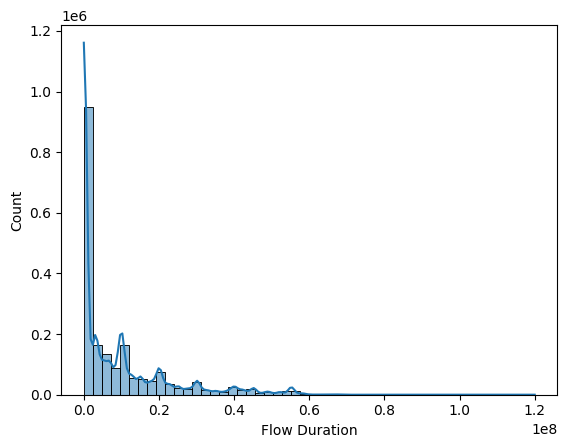

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Flow Duration'], bins=50, kde=True)
plt.show()

In [14]:
# corr = df.corr(numeric_only=True)
# sns.heatmap(corr, annot=True, cmap='coolwarm')
# plt.show()

In [15]:

df['Traffic Type'].value_counts() ,df['Label'].value_counts() , df['Traffic Subtype'].value_counts()

(Traffic Type
 DoS                      1730294
 Information Gathering     240295
 Mirai                      20986
 Bruteforce                  8133
 Video                        198
 Audio                         44
 Text                          41
 Background                     9
 Name: count, dtype: int64,
 Label
 Malicious    1999708
 Benign           292
 Name: count, dtype: int64,
 Traffic Subtype
 DoS RST                  247761
 Information Gathering    240295
 DoS ACK                  216394
 DoS PSH                  209630
 DoS URG                  209502
 DoS CWR                  201273
 DoS ECN                  201045
 DoS SYN                  198554
 DoS FIN                  167356
 DoS UDP                   59747
 DoS HTTP                  19023
 Mirai DDoS DNS            12719
 Bruteforce DNS             5057
 Mirai DDoS SYN             3233
 Mirai DDoS HTTP            2083
 Mirai Scan Bruteforce      2020
 Bruteforce Telnet          1134
 Bruteforce SSH              

In [16]:
#sns.pairplot(df, hue='Label', vars=['Flow Duration','Fwd Packet Length Mean','Bwd Packet Length Mean'])#
#plt.show()

In [17]:
df = df.drop_duplicates()

In [18]:
df.head(4)

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWR Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Fwd Segment Size Avg,Bwd Segment Size Avg,Fwd Bytes/Bulk Avg,Fwd Packet/Bulk Avg,Fwd Bulk Rate Avg,Bwd Bytes/Bulk Avg,Bwd Packet/Bulk Avg,Bwd Bulk Rate Avg,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,FWD Init Win Bytes,Bwd Init Win Bytes,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Traffic Type,Traffic Subtype
5184976,192.168.1.70-192.168.1.90-32098-0-6,192.168.1.70,32098.0,192.168.1.90,0,6.0,01/01/1970 10:54:05 PM,168035.0,1.0,1.0,500.0,0.0,500.0,500.0,500.0,0.0,0.0,0.0,0.0,0.0,2975.570566,11.902282,1.680350e+05,0.000000e+00,168035.0,168035.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,20.0,5.951141,5.951141,0.0,500.0,333.333333,288.675135,83333.333333,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,500.0,500.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,512.0,0.0,0.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Malicious,DoS,DoS ECN
7630969,192.168.1.70-192.168.1.90-1424-10107-6,192.168.1.70,1424.0,192.168.1.90,10107,6.0,01/01/1970 07:45:26 AM,3867299.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.517157,3.867299e+06,0.000000e+00,3867299.0,3867299.0,3867299.0,3867299.0,0.000000e+00,3867299.0,3867299.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,40.0,0.0,0.517157,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,512.0,0.0,0.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Malicious,Information Gathering,Information Gathering
3791453,192.168.1.70-192.168.1.90-2991-0-6,192.168.1.70,2991.0,192.168.1.90,0,6.0,01/01/1970 10:39:00 PM,10043849.0,3.0,1.0,150.0,0.0,50.0,50.0,50.0,0.0,0.0,0.0,0.0,0.0,14.934514,0.398254,3.347950e+06,2.989687e+06,5849726.0,36948.0,10006901.0,5003450.5,1.196814e+06,5849726.0,4157175.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,60.0,20.0,0.298690,0.099563,0.0,50.0,40.000000,22.360680,500.000000,0.0,3.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,50.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,75.0,0.0,0.0,512.0,0.0,2.0,20.0,4157175.0,0.0,4157175.0,4157175.0,5849726.0,0.0,5849726.0,5849726.0,Malicious,DoS,DoS SYN
2896203,192.168.1.70-192.168.1.90-31411-0-6,192.168.1.70,31411.0,192.168.1.90,0,6.0,01/01/1970 05:02:21 AM,10028903.0,3.0,1.0,1500.0,0.0,500.0,500.0,500.0,0.0,0.0,0.0,0.0,0.0,149.567704,0.398847,3.342968e+06,3.466190e+06,6943233.0,28557.0,10000346.0,5000173.0,2.747902e+06,6943233.0,3057113.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,60.0,20.0,0.299135,0.099712,0.0,500.0,400.000000,223.606798,50000.000000,0.0,0.0,1.0,0.0,1.0,3.0,0.0,0.0,0.0,500.0,500.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,750.0,0.0,0.0,512.0,0.0,2.0,20.0,3057113.0,0.0,3057113.0,3057113.0,6943233.0,0.0,6943233.0,6943233.0,Malicious,DoS,DoS URG


In [19]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

df['hour'] = df['Timestamp'].dt.hour
df['day'] = df['Timestamp'].dt.day
df['weekday'] = df['Timestamp'].dt.weekday

/tmp/ipykernel_507/4183626997.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Timestamp'] = pd.to_datetime(df['Timestamp'])


In [20]:
drop_col = ["Flow ID" , "Src IP"  ,"Dst IP" , "Timestamp"]
df =df.drop(drop_col , axis=1)

In [21]:
cat_col = df.select_dtypes(include="object").columns

In [22]:
for col in cat_col:
  print(df[col].nunique())
  print(pd.unique(df[col]))
  print("_"*10)

2
['Malicious' 'Benign']
__________
8
['DoS' 'Information Gathering' 'Mirai' 'Bruteforce' 'Video' 'Audio' 'Text'
 'Background']
__________
32
['DoS ECN' 'Information Gathering' 'DoS SYN' 'DoS URG' 'DoS FIN' 'DoS PSH'
 'DoS RST' 'DoS UDP' 'DoS CWR' 'DoS ACK' 'DoS HTTP' 'Mirai DDoS DNS'
 'Bruteforce DNS' 'Mirai Scan Bruteforce' 'Bruteforce SSH'
 'Mirai DDoS SYN' 'Mirai DDoS HTTP' 'Bruteforce FTP' 'Mirai DDoS ACK'
 'Bruteforce Telnet' 'Video RTP' 'Video HTTP' 'Mirai DDoS UDP' 'Audio'
 'Mirai DDoS GREIP' 'Video UDP' 'Bruteforce HTTP' 'Text'
 'Mirai DDoS GREETH' 'DoS MAC' 'Background' 'DoS ICMP']
__________


In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in cat_col:
    df[col] = le.fit_transform(df[col])

In [24]:
y_label = df['Label']
X = df.drop(['Label',"Traffic Type" , "Traffic Subtype"], axis=1)

In [25]:
y_Traffic_Type = df['Traffic Type']
y_Traffic_subtype = df['Traffic Subtype' ]


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# split مرة واحدة
X_train, X_test, y_label_train, y_label_test, y_type_train, y_type_test, y_sub_train, y_sub_test = train_test_split(
    X_scaled,
    y_label,
    y_Traffic_Type,
    y_Traffic_subtype,
    test_size=0.2,
    random_state=42
)

In [27]:
X_train.shape , X_test.shape , y_label_train.shape , y_label_test.shape

((1599927, 82), (399982, 82), (1599927,), (399982,))

In [28]:
import tensorflow as tf

def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        pt = tf.exp(-bce)
        return alpha * (1 - pt)**gamma * bce
    return loss

2026-03-21 19:18:04.384938: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774120684.566378     507 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774120684.589150     507 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774120684.937611     507 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774120684.937650     507 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774120684.937654     507 computation_placer.cc:177] computation placer alr

In [29]:
import keras

input_ = keras.layers.Input(shape=(82,))
x = keras.layers.Dense(283, activation='sigmoid')(input_)
x = keras.layers.Dense(141, activation='sigmoid')(x)
x = keras.layers.Dense(200, activation='sigmoid')(x)
x = keras.layers.Dense(200, activation='sigmoid')(x)
x = keras.layers.Dropout(0.6)(x)
# outputs
output1 = keras.layers.Dense(1, activation='sigmoid', name="label")(x)
output2 = keras.layers.Dense(8, activation='softmax', name="Traffic_Type")(x)
output3 = keras.layers.Dense(32, activation='softmax', name="Traffic_Subtype")(x)

model = keras.models.Model(
    inputs=input_,
    outputs=[output1, output2, output3]
)

model.compile(
    optimizer='adam',
    loss={
        'label': 'binary_crossentropy',
        'Traffic_Type': 'sparse_categorical_crossentropy',
        'Traffic_Subtype': 'sparse_categorical_crossentropy'
    },
    metrics={
        'label': 'accuracy',
        'Traffic_Type': 'accuracy',
        'Traffic_Subtype': 'accuracy'
    }
)

2026-03-21 19:18:16.757508: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [30]:

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 82)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 283)       │     23,489 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 141)       │     40,044 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 200)       │     28,400 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 200)       │     40,200 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 200)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ label (Dense)       │ (None, 1)         │        201 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Traffic_Type        │ (None, 8)         │      1,608 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Traffic_Subtype     │ (None, 32)        │      6,432 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 140,374 (548.34 KB)

 Trainable params: 140,374 (548.34 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
from keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor='accuracy',   
    patience=3,           
    restore_best_weights=True  )

In [32]:
history = model.fit(
    X_train,
    {
        'label': y_label_train,
        'Traffic_Type': y_type_train,
        'Traffic_Subtype': y_sub_train
    },

    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
49998/49998 ━━━━━━━━━━━━━━━━━━━━ 219s 4ms/step - Traffic_Subtype_accuracy: 0.9420 - Traffic_Subtype_loss: 0.1878 - Traffic_Type_accuracy: 0.9928 - Traffic_Type_loss: 0.0294 - label_accuracy: 0.9997 - label_loss: 0.0021 - loss: 0.2194
Epoch 2/10
   14/49998 ━━━━━━━━━━━━━━━━━━━━ 3:21 4ms/step - Traffic_Subtype_accuracy: 1.0000 - Traffic_Subtype_loss: 3.8066e-04 - Traffic_Type_accuracy: 1.0000 - Traffic_Type_loss: 2.0524e-05 - label_accuracy: 1.0000 - label_loss: 3.0040e-06 - loss: 4.0419e-04     

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `accuracy` which is not available. Available metrics are: Traffic_Subtype_accuracy,Traffic_Subtype_loss,Traffic_Type_accuracy,Traffic_Type_loss,label_accuracy,label_loss,loss
  current = self.get_monitor_value(logs)


49998/49998 ━━━━━━━━━━━━━━━━━━━━ 230s 5ms/step - Traffic_Subtype_accuracy: 0.9982 - Traffic_Subtype_loss: 0.0092 - Traffic_Type_accuracy: 0.9994 - Traffic_Type_loss: 0.0025 - label_accuracy: 0.9999 - label_loss: 6.1283e-04 - loss: 0.0124
Epoch 3/10
49998/49998 ━━━━━━━━━━━━━━━━━━━━ 207s 4ms/step - Traffic_Subtype_accuracy: 0.9988 - Traffic_Subtype_loss: 0.0065 - Traffic_Type_accuracy: 0.9996 - Traffic_Type_loss: 0.0020 - label_accuracy: 0.9999 - label_loss: 4.0382e-04 - loss: 0.0089
Epoch 4/10
49998/49998 ━━━━━━━━━━━━━━━━━━━━ 199s 4ms/step - Traffic_Subtype_accuracy: 0.9990 - Traffic_Subtype_loss: 0.0055 - Traffic_Type_accuracy: 0.9997 - Traffic_Type_loss: 0.0016 - label_accuracy: 0.9999 - label_loss: 4.3183e-04 - loss: 0.0075
Epoch 5/10
49998/49998 ━━━━━━━━━━━━━━━━━━━━ 203s 4ms/step - Traffic_Subtype_accuracy: 0.9991 - Traffic_Subtype_loss: 0.0049 - Traffic_Type_accuracy: 0.9997 - Traffic_Type_loss: 0.0016 - label_accuracy: 0.9999 - label_loss: 4.0123e-04 - loss: 0.0068
Epoch 6/10
4999

In [51]:
model.save('my_model.keras')

In [44]:
y_pred_label_, y_pred_type_, y_pred_subtype_ = model.predict(X_train)

49998/49998 ━━━━━━━━━━━━━━━━━━━━ 89s 2ms/step


In [45]:
import numpy as np

# label binary
y_pred_label_class_ = (y_pred_label_ > 0.3).astype(int)

# Traffic Type
y_pred_type_class_= np.argmax(y_pred_type_, axis=1)

# Traffic Subtype
y_pred_subtype_class_ = np.argmax(y_pred_subtype_, axis=1)

In [46]:
from sklearn.metrics import confusion_matrix, classification_report

# label
print(confusion_matrix(y_label_train, y_pred_label_class_))
print(classification_report(y_label_train, y_pred_label_class_))

# Traffic Type
print(confusion_matrix(y_type_train, y_pred_type_class_))
print(classification_report(y_type_train, y_pred_type_class_))

# Traffic Subtype
print(confusion_matrix(y_sub_train, y_pred_subtype_class_))
print(classification_report(y_sub_train, y_pred_subtype_class_))

[[    175      63]
 [      9 1599680]]
              precision    recall  f1-score   support

           0       0.95      0.74      0.83       238
           1       1.00      1.00      1.00   1599689

    accuracy                           1.00   1599927
   macro avg       0.98      0.87      0.91   1599927
weighted avg       1.00      1.00      1.00   1599927

[[      0       0       0       5       0       0       0      30]
 [      0       0       0       0       0       0       0       6]
 [      0       0    6520      27       0       0       0       4]
 [      0       0      10 1383874       5       1       0       6]
 [      0       0      10       8  192474       0       0       7]
 [      0       0       2       1       1   16730       0       9]
 [      0       0       1       1       0       0       0      33]
 [      0       0       2      19       5       0       0     136]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00        35
           1       0.00      0.00      0.00         6
           2       1.00      1.00      1.00      6551
           3       1.00      1.00      1.00   1383896
           4       1.00      1.00      1.00    192499
           5       1.00      1.00      1.00     16743
           6       0.00      0.00      0.00        35
           7       0.59      0.84      0.69       162

    accuracy                           1.00   1599927
   macro avg       0.57      0.60      0.59   1599927
weighted avg       1.00      1.00      1.00   1599927

[[   1    0    0 ...   26    4    0]
 [   0    0    0 ...    6    0    0]
 [   0    0 4074 ...    0    0    0]
 ...
 [   1    0    0 ...   54   11    0]
 [   0    0    0 ...    4   54    0]
 [   0    0    0 ...    7   17    0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.50      0.03      0.05        35
           1       0.00      0.00      0.00         6
           2       1.00      1.00      1.00      4074
           3       1.00      0.99      0.99       682
           4       0.99      0.96      0.97       115
           5       0.94      0.99      0.96       753
           6       1.00      0.95      0.97       927
           7       1.00      1.00      1.00    173281
           8       1.00      1.00      1.00    161127
           9       1.00      1.00      1.00    160586
          10       1.00      1.00      1.00    133715
          11       1.00      1.00      1.00     15173
          12       0.00      0.00      0.00         1
          13       0.00      0.00      0.00         7
          14       1.00      1.00      1.00    167728
          15       1.00      1.00      1.00    198035
          16       1.00      1.00      1.00    158963
          17       1.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [33]:
y_pred_label, y_pred_type, y_pred_subtype = model.predict(X_test)

12500/12500 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step


In [34]:
pd.Series([y_pred_label]).value_counts()

[[1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [0.11418509], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], ...]    1
Name: count, dtype: int64

In [42]:
import numpy as np

# label binary
y_pred_label_class = (y_pred_label > 0.3).astype(int)

# Traffic Type
y_pred_type_class = np.argmax(y_pred_type, axis=1)

# Traffic Subtype
y_pred_subtype_class = np.argmax(y_pred_subtype, axis=1)

In [43]:
from sklearn.metrics import confusion_matrix, classification_report

# label
print(confusion_matrix(y_label_test, y_pred_label_class))
print(classification_report(y_label_test, y_pred_label_class))

# Traffic Type
print(confusion_matrix(y_type_test, y_pred_type_class))
print(classification_report(y_type_test, y_pred_type_class))

# Traffic Subtype
print(confusion_matrix(y_sub_test, y_pred_subtype_class))
print(classification_report(y_sub_test, y_pred_subtype_class))

[[    43     11]
 [     1 399927]]
              precision    recall  f1-score   support

           0       0.98      0.80      0.88        54
           1       1.00      1.00      1.00    399928

    accuracy                           1.00    399982
   macro avg       0.99      0.90      0.94    399982
weighted avg       1.00      1.00      1.00    399982

[[     0      0      0      1      0      0      0      8]
 [     0      0      0      1      0      0      0      2]
 [     0      0   1572      8      1      1      0      0]
 [     0      0      4 346390      1      1      0      2]
 [     0      0      3      3  47788      0      0      2]
 [     0      0      0      0      0   4151      0      1]
 [     0      0      0      1      0      0      0      5]
 [     0      0      0      2      2      0      0     32]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.00      0.00      0.00         3
  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[[    0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     1     0     0     0     0     0     0     0     0
      0     0     0     0     8     0     0]
 [    0     0     0     0     0     0     0     1     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     2     0     0]
 [    0     0   983     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0]
 [    0     0     0   163     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0]
 [    0     0     0     0    31     0     0     0     0     1     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0]
 [    0     0     0     0     0   1

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
